# Pune Property Analysis🏠


## 02. Exploratory Data Analysis
After completing data cleaning and preprocessing, the cleaned dataset was saved and reloaded to ensure consistency before performing exploratory data analysis.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [4]:
data = pd.read_csv('/content/cleaned_pune_property_ds.csv')

In [5]:
data.head()

,balconies,bathroom,facing,locality,opensides,price,totalfloor,no. of additional rooms,studyroom,poojaroom,...,AC,Wardrobe,TV,Refrigerator,Sofa,Washing Machine,Wifi,Microwave,Dining Table,Gas connection
0,2.0,3.0,West,Deccan Gymkhana,2.0,27000000,6.0,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
1,NaN,2.0,NorthEast,Kharadi,NaN,7610050,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
2,NaN,1.0,NorthEast,Sus,NaN,4100000,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
3,NaN,2.0,NorthEast,Bavdhan,NaN,5736000,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
4,1.0,3.0,West,Deccan Gymkhana,2.0,29002000,9.0,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29301 entries, 0 to 29300
Data columns (total 73 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   balconies                17534 non-null  float64
 1   bathroom                 27466 non-null  float64
 2   facing                   24397 non-null  object 
 3   locality                 29301 non-null  object 
 4   opensides                8367 non-null   float64
 5   price                    29301 non-null  int64  
 6   totalfloor               19212 non-null  float64
 7   no. of additional rooms  7234 non-null   float64
 8   studyroom                7234 non-null   object 
 9   poojaroom                7234 non-null   object 
 10  servantroom              7234 non-null   object 
 11  age of house             22166 non-null  float64
 12  total area               29288 non-null  float64
 13  total rooms              28673 non-null  float64
 14  apartment             

In [7]:
data["price (crore)"] = data["price"]/1e7

In [8]:
sns.set_theme(style="whitegrid",
              rc= {"grid.linestyle" : "--" },
              palette = "pastel")
plt.rcParams["figure.figsize"] = (8,5)

# ***1. Target Variable***

## 1. Price Distribution (Target)
Helps us understand price skewness

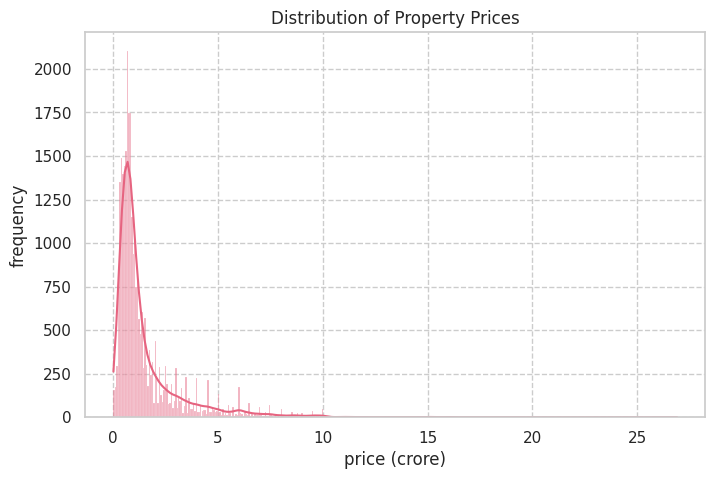

In [9]:
sns.histplot(data["price (crore)"], kde= True, color="#e66480")
plt.title("Distribution of Property Prices")
plt.ylabel("frequency")
plt.grid(axis = "y", linestyle ="--" )
plt.show()

# 2. Numerical Feature

## 2. Average price for each room count

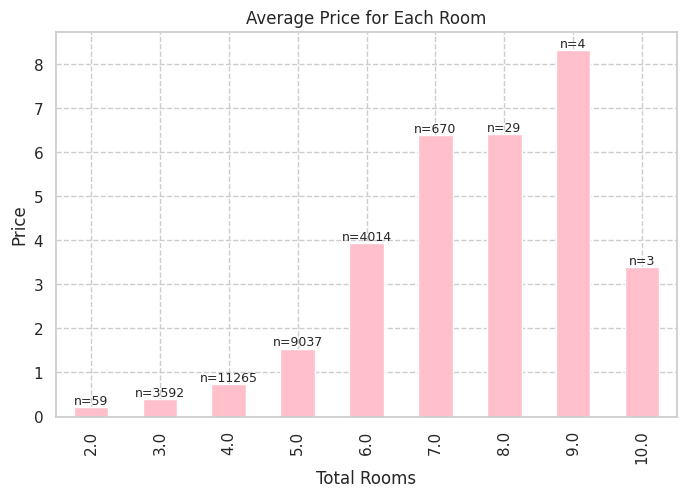

In [10]:
total_rooms_price = data.groupby('total rooms')['price (crore)'].mean()
total_rooms_price.plot(kind='bar',color = "pink")
plt.xlabel('Total Rooms')
plt.ylabel('Price')
plt.title("Average Price for Each Room")

for i, count in enumerate(data['total rooms'].value_counts().sort_index()):
    plt.text(i, total_rooms_price.iloc[i], f'n={count}', ha='center', va='bottom', fontsize=9)

plt.show()

## 3. Total Area vs Price
Shows how strongly property size influences price and detects outliers

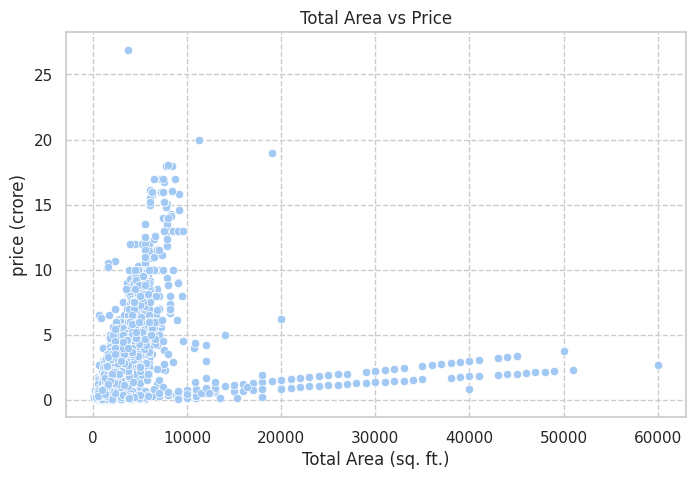

In [11]:
sns.scatterplot(x='total area', y='price (crore)', data=data)
plt.title("Total Area vs Price")
plt.xlabel('Total Area (sq. ft.)')
plt.show()

## 4. Carpet Area vs Price
Helps verify whether carpet area is a stronger predictor than total area

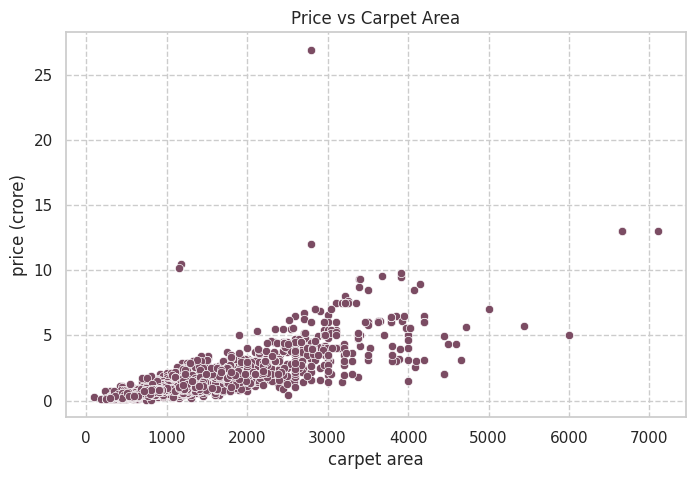

In [12]:
sns.scatterplot(data = data, x = "carpet area", y = "price (crore)", color = "#7B4C63")
plt.title("Price vs Carpet Area")
plt.show()

## 5. Price vs Age of House
Helps analyze depreciation effect of older properties on price

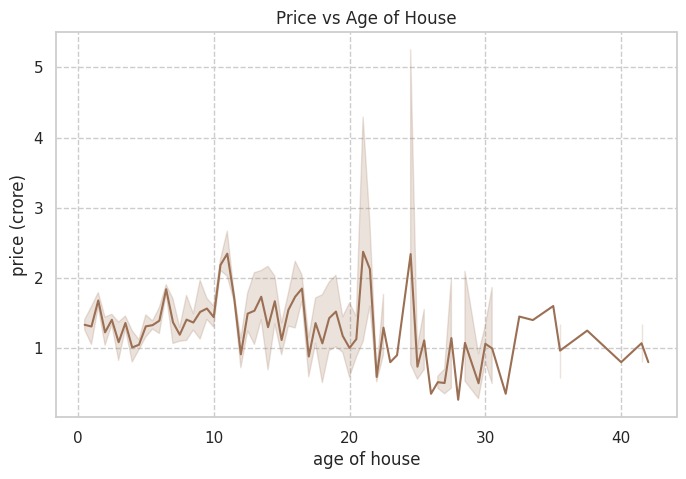

In [13]:
sns.lineplot(data=data, x='age of house', y='price (crore)', color = "#9b6f53")
plt.title("Price vs Age of House")
plt.show()

In [14]:
data["age of house"].unique()

array([ 2.5,  0.5,  1.5,  nan,  6.5,  2. ,  3.5, 10.5,  7.5,  4.5,  5.5,
       12.5, 11.5,  1. , 17. ,  6. , 12. ,  7. , 20. , 20.5,  9.5, 13.5,
       19.5, 14.5, 15. , 17.5,  8.5, 19. , 25. , 30. ,  3. , 18.5, 26.5,
       11. , 21.5, 16.5, 15.5, 30.5, 28.5,  5. ,  4. ,  9. , 10. ,  8. ,
       13. , 22.5, 18. , 21. , 22. , 14. , 16. , 27.5, 28. , 24.5, 25.5,
       40. , 37.5, 35.5, 35. , 41.5, 29.5, 27. , 31.5, 42. , 33.5, 23. ,
       32.5, 26. , 23.5])

##6. Balconies vs Price

<Axes: xlabel='balconies', ylabel='price (crore)'>

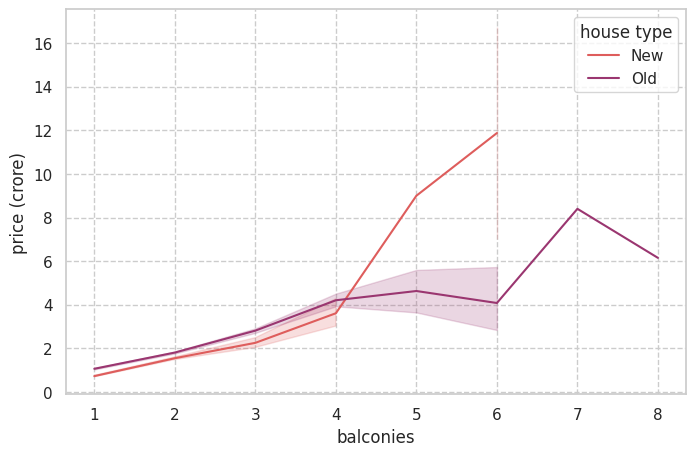

In [15]:
sns.lineplot(data=data, x='balconies', y='price (crore)', palette="flare", hue ="house type")

##7. Price vs Bathroom

<Axes: xlabel='bathroom', ylabel='price (crore)'>

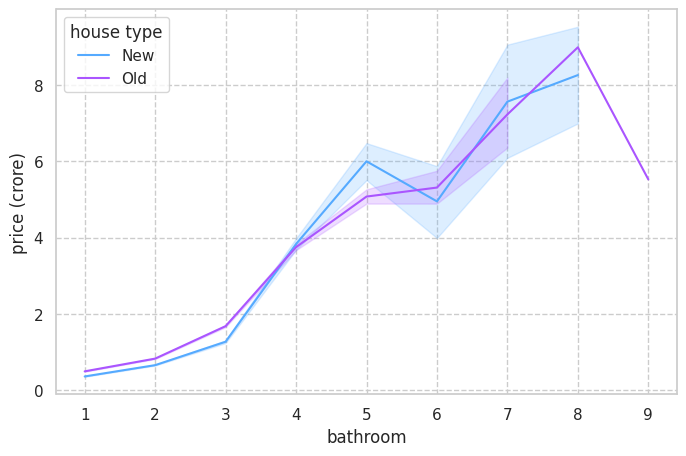

In [16]:
sns.lineplot(data=data, x='bathroom', y='price (crore)', palette="cool", hue ="house type")

# ***3. Categorical Feature***

## 1. Price by House Type

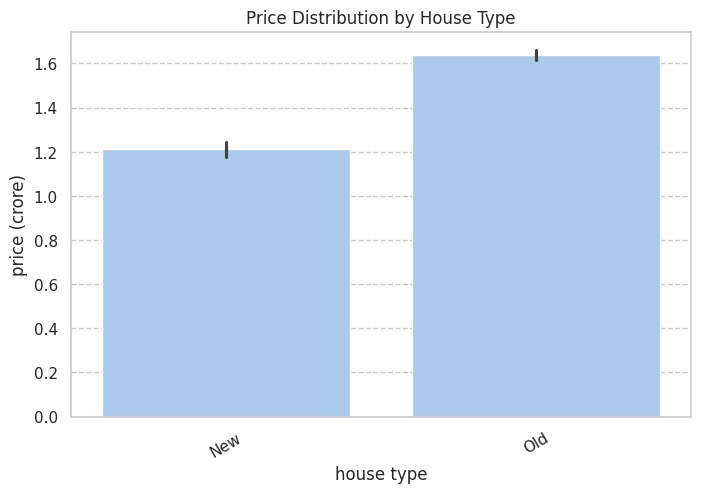

In [17]:
sns.barplot(x='house type', y='price (crore)', data=data)
plt.title("Price Distribution by House Type")
plt.xticks(rotation=30)
plt.show()


## 2. Locality vs Price (top 10)

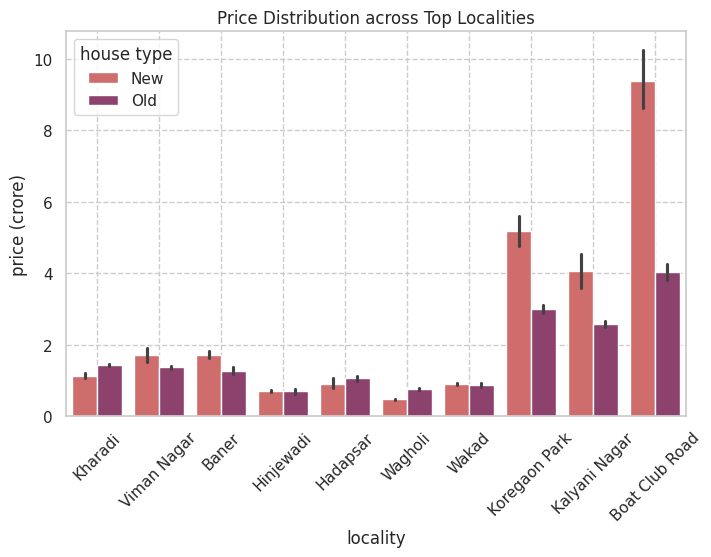

In [18]:
top_localities = data['locality'].value_counts(ascending=False).head(10).index
filtered_df = data[data['locality'].isin(top_localities)]

sns.barplot(x='locality', y='price (crore)', data=filtered_df, hue="house type", palette="flare")
plt.xticks(rotation=45)
plt.title("Price Distribution across Top Localities")
plt.grid(axis = "x", linestyle ="--" )
plt.show()


In [19]:
data['locality'].value_counts(ascending=False).head(10)
# filtered_df = data[data['locality'].isin(top_localities)]
# filtered_df

,count
locality,
Kharadi,4280
Viman Nagar,3067
Kalyani Nagar,2820
Wagholi,2594
Koregaon Park,2208
Hadapsar,1286
Baner,987
Wakad,796
Hinjewadi,790


In [20]:
data.columns

Index(['balconies', 'bathroom', 'facing', 'locality', 'opensides', 'price',
       'totalfloor', 'no. of additional rooms', 'studyroom', 'poojaroom',
       'servantroom', 'age of house', 'total area', 'total rooms', 'apartment',
       'residential', 'penthouse', 'independent', 'villa', 'carpet area',
       'floors', 'house type', 'road view', 'garden view', 'phool view',
       'corner view', 'co-operative society', 'freehold property',
       'power of attorney', 'leasehold', 'possesion year', 'possesion month',
       'road feet', 'ready to move', 'unfurnished', 'under construction',
       'semi furnished', 'furnished', 'BED', 'Lift Available', 'Car Parking',
       'Power Backup', '24 X 7 Security', 'Children's play area',
       'Vaastu Compliant', 'Club House', 'Gymnasium', 'Swimming Pool',
       'Sports Facility', 'Indoor Games', 'Jogging Track', 'Maintenance Staff',
       'Intercom', 'Golf Course', 'Cafeteria', 'Rain Water Harvesting',
       'Staff Quarter', 'Multipurpose

In [21]:
def furnishing_stat(x):
  if x["under construction"] == "Yes":
    return "Under Construction"
  elif x["semi furnished"] == "Yes":
    return "Semi Furnished"
  elif x["unfurnished"] == "Yes":
    return "Unfurnished"
  elif x["furnished"] == "Yes":
    return "Furnished"
  else:
    return "Unknown"

data["furnishing_status"] = data.apply(furnishing_stat, axis=1)


In [22]:
print(data[["furnished", "semi furnished", "unfurnished", "under construction"]].eq("Yes").sum())
print("\n Unique")
print(data["furnishing_status"].unique())


furnished             20920
semi furnished            0
unfurnished           14131
under construction     4155
dtype: int64

 Unique
['Unknown' 'Unfurnished' 'Under Construction' 'Furnished']


##3. Price vs Furnishing Status


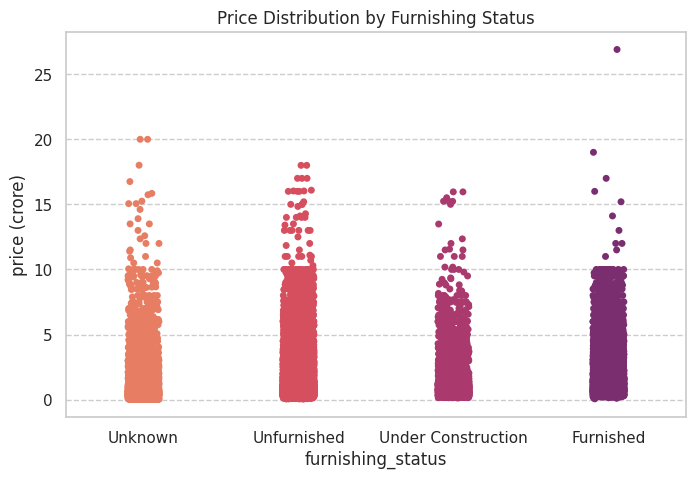

In [23]:
sns.stripplot(data = data, x = "furnishing_status", y = "price (crore)", palette="flare")
plt.title("Price Distribution by Furnishing Status")
plt.show()

##4. Price Distribution Across House Types
Comparing property prices across different house types with respective Furnished or Unfurnished house, revealing that villas and penthouses generally fall into higher price ranges than apartments.

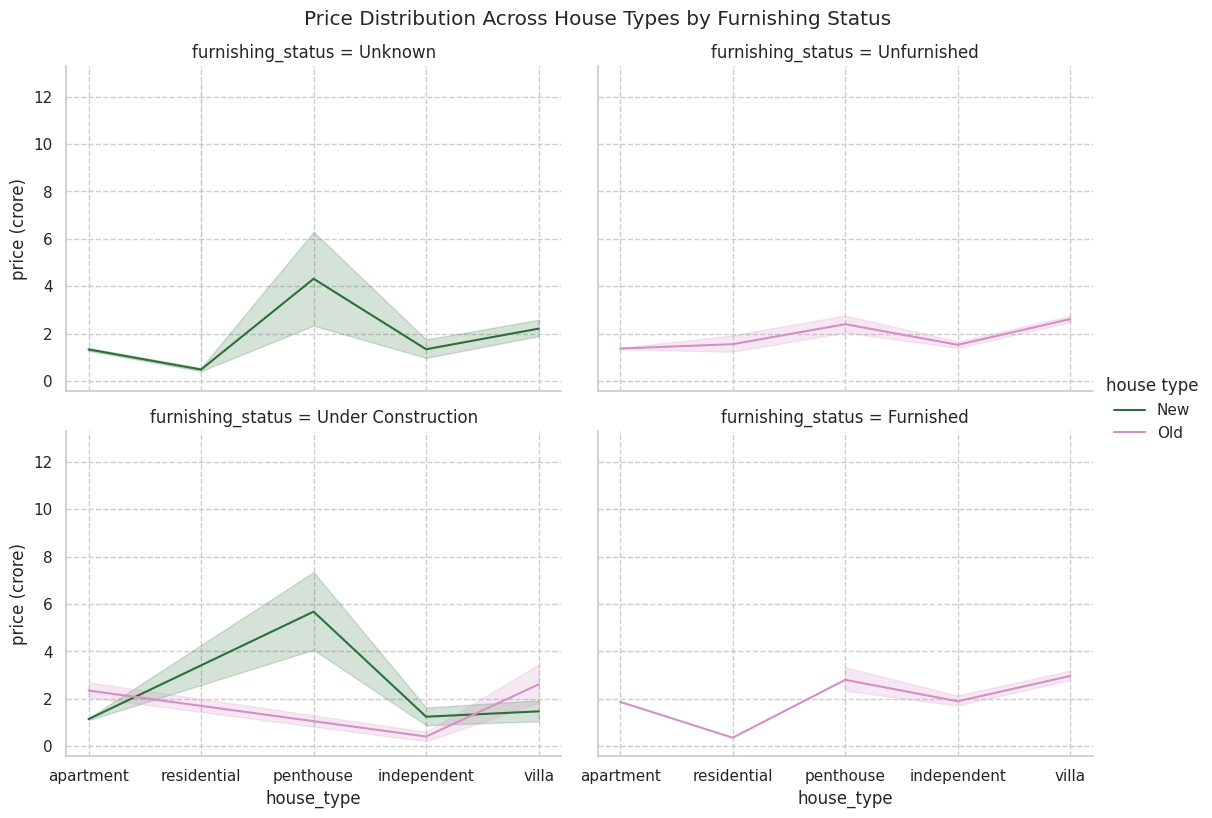

In [24]:
# Melt is used to convert one-hot encoded categorical columns into a single categorical column for better analysis and visualization.
# Melt converts wide data into long data by reducing the number of columns and increasing the number of rows.

house_col = ["apartment", "residential", "penthouse", "independent", "villa"]

house_data = data.melt(id_vars=["price (crore)","furnishing_status", "house type"], value_vars= house_col, var_name="house_type", value_name= "is_present")
house_data = house_data[house_data["is_present"] == "Yes"]

sns.relplot(data=house_data,x="house_type",y="price (crore)",kind="line", hue = "house type", palette="cubehelix", col= "furnishing_status", aspect=1.4, col_wrap =2, height=4)

plt.suptitle("Price Distribution Across House Types by Furnishing Status", y=1.02)
plt.show()



## 5. Price vs Facing

Text(0.5, 1.0, 'Price Distribution by Facing Direction')

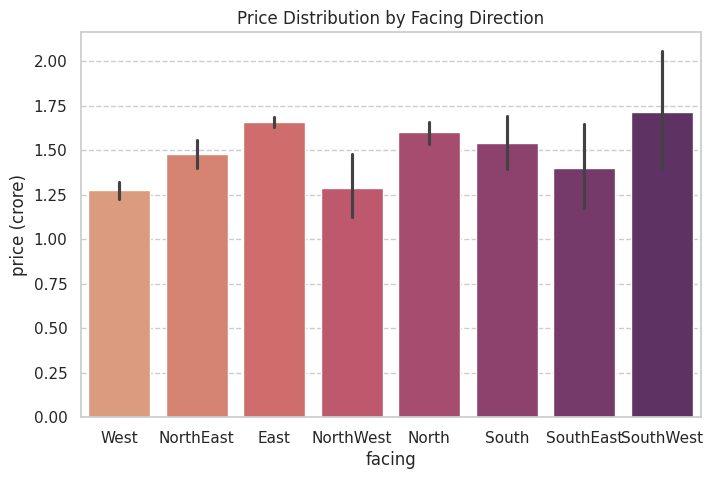

In [26]:
sns.barplot(data=data, x= "facing", y= "price (crore)", palette="flare")
plt.title("Price Distribution by Facing Direction")